# 3 · Orthogonality — and why it is not the dot product

**Math primer — notebook 3 of 7.**

The word "orthogonal" in the paper's title does *not* mean the mode shapes are
perpendicular in the ordinary sense. They usually are not. They are orthogonal
*with respect to the mass matrix*, and that distinction is the reason the whole
method works.

**You should come out knowing:** what $\{u^s\}^\mathsf{T}[M]\{u^r\}=0$ means and
where it comes from, how it turns coupled equations into independent
single-degree-of-freedom oscillators, and what modal mass actually is.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh
import primer
from primer import SERIES, INK, INK2, GRID, tidy
primer.use_style()

In [2]:
m1, m2 = 2.0, 1.0
k1, k2 = 800.0, 400.0
M = np.diag([m1, m2])
K = np.array([[k1 + k2, -k2], [-k2, k2]])
w2, V = eigh(K, M)
V = V / V[np.argmax(np.abs(V), axis=0), np.arange(2)]   # largest entry = 1
omega = np.sqrt(w2)
print("shapes:\n", V)
print("\nplain dot product u1 . u2 =", V[:, 0] @ V[:, 1], "   <- NOT zero")
print("M-weighted   u1^T M u2   =", V[:, 0] @ M @ V[:, 1], "   <- zero")
print("K-weighted   u1^T K u2   =", V[:, 0] @ K @ V[:, 1], "   <- zero")

shapes:
 [[ 0.5  1. ]
 [ 1.  -1. ]]

plain dot product u1 . u2 = -0.5    <- NOT zero
M-weighted   u1^T M u2   = -1.1102230246251565e-16    <- zero
K-weighted   u1^T K u2   = -1.4210854715202004e-13    <- zero


## 3.1 · Where it comes from

Three lines. Take two modes $r\ne s$:

$$[K]\{u^r\}=\omega_r^2[M]\{u^r\},\qquad [K]\{u^s\}=\omega_s^2[M]\{u^s\}$$

Pre-multiply the first by $\{u^s\}^\mathsf{T}$ and the second by
$\{u^r\}^\mathsf{T}$:

$$\{u^s\}^\mathsf{T}[K]\{u^r\}=\omega_r^2\{u^s\}^\mathsf{T}[M]\{u^r\}$$
$$\{u^r\}^\mathsf{T}[K]\{u^s\}=\omega_s^2\{u^r\}^\mathsf{T}[M]\{u^s\}$$

Because $[M]$ and $[K]$ are symmetric, the left-hand sides are equal and the
$[M]$-products on the right are equal. Subtract:

$$0=\left(\omega_r^2-\omega_s^2\right)\{u^s\}^\mathsf{T}[M]\{u^r\}$$

If the frequencies differ, the $[M]$-product must vanish. And then the
$[K]$-product vanishes too. That is the paper's Eqs. (4) and (5).

Note the two things the proof needed: **symmetry** of $[M]$ and $[K]$ (which
notebook 1 showed is automatic for springs), and **distinct frequencies** (which
notebook 2 showed can fail).

In [3]:
# The full orthogonality tables.
print("V^T M V =\n", V.T @ M @ V)
print("\nV^T K V =\n", V.T @ K @ V)
print("\nOff-diagonals are zero to machine precision; the diagonals are the")
print("MODAL MASS m_r and MODAL STIFFNESS k_r, and k_r / m_r = w_r^2:")
mr = np.diag(V.T @ M @ V)
kr = np.diag(V.T @ K @ V)
print("  m_r =", mr)
print("  k_r =", kr)
print("  k_r/m_r      =", kr / mr)
print("  w_r^2        =", w2)

V^T M V =
 [[ 1.5 -0. ]
 [-0.   3. ]]

V^T K V =
 [[ 300.   -0.]
 [  -0. 2400.]]

Off-diagonals are zero to machine precision; the diagonals are the
MODAL MASS m_r and MODAL STIFFNESS k_r, and k_r / m_r = w_r^2:
  m_r = [1.5 3. ]
  k_r = [ 300. 2400.]
  k_r/m_r      = [200. 800.]
  w_r^2        = [200. 800.]


## 3.2 · Geometric picture

Ordinary orthogonality means perpendicular. $[M]$-orthogonality means
perpendicular *after* the space has been stretched by the mass distribution. Draw
both: the unit circle becomes an ellipse whose axes are set by $[M]$, and the two
mode shapes are conjugate diameters of that ellipse.

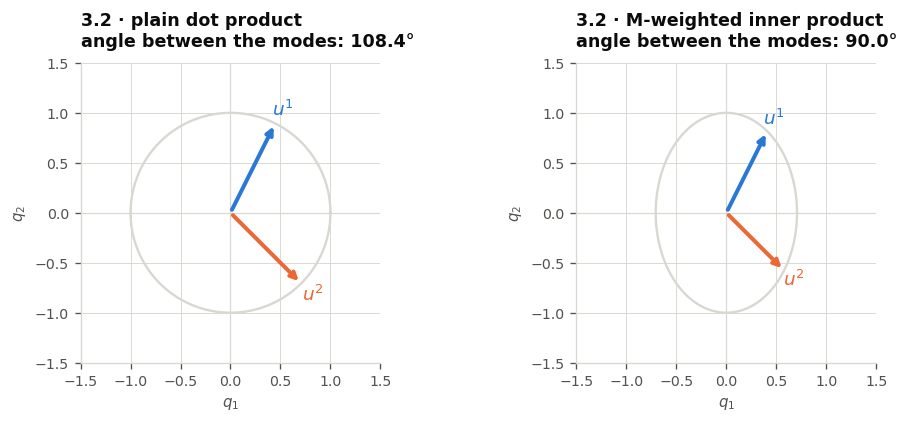

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(8.4, 3.6))

th = np.linspace(0, 2*np.pi, 400)
circle = np.vstack([np.cos(th), np.sin(th)])

for ax, A, name in ((axes[0], np.eye(2), "plain dot product"),
                    (axes[1], M, "M-weighted inner product")):
    # {x : x^T A x = 1}
    L = np.linalg.cholesky(np.linalg.inv(A))
    ell = L @ circle
    ax.plot(ell[0], ell[1], color=GRID, lw=1.4)
    for r in range(2):
        u = V[:, r] / np.sqrt(V[:, r] @ A @ V[:, r])
        ax.annotate("", xy=(u[0], u[1]), xytext=(0, 0),
                    arrowprops=dict(arrowstyle="->", color=SERIES[r], lw=2.4))
        ax.text(u[0]*1.16, u[1]*1.16, f"$u^{r+1}$", color=SERIES[r], fontsize=11,
                ha="center", va="center")
    ang = np.degrees(np.arccos(
        (V[:, 0] @ A @ V[:, 1]) /
        np.sqrt((V[:, 0] @ A @ V[:, 0]) * (V[:, 1] @ A @ V[:, 1]))))
    ax.set_aspect("equal"); ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
    ax.axhline(0, color=GRID, lw=0.7); ax.axvline(0, color=GRID, lw=0.7)
    tidy(ax, f"3.2 · {name}\nangle between the modes: {ang:.1f}°", "$q_1$", "$q_2$")
plt.tight_layout(); plt.show()

Same two vectors, two different notions of "the angle between them". In the
$[M]$-weighted geometry they are exactly 90° apart. **That** is the orthogonality
the paper is talking about.

## 3.3 · The payoff: decoupling

Collect the modes as columns of $[\Phi]$ and change coordinates with
$\{q\}=[\Phi]\{\eta\}$. Apply the congruence transform from notebook 1:

$$[\Phi]^\mathsf{T}[M][\Phi]\{\ddot\eta\}+[\Phi]^\mathsf{T}[K][\Phi]\{\eta\}
=[\Phi]^\mathsf{T}\{f\}$$

Both transformed matrices are **diagonal** — that is exactly what orthogonality
says. So the coupled system has become $n$ independent scalar equations:

$$m_r\ddot\eta_r + k_r\eta_r = \{u^r\}^\mathsf{T}\{f\},\qquad r=1\ldots n$$

Each is a single mass on a single spring. This is what "modal analysis" buys you,
and it is the machinery behind the paper's Eq. (6).

Phi^T M Phi =
 [[ 1.5 -0. ]
 [-0.   3. ]]

Phi^T K Phi =
 [[ 300.   -0.]
 [  -0. 2400.]]

Off-diagonal magnitudes: 1.42e-13


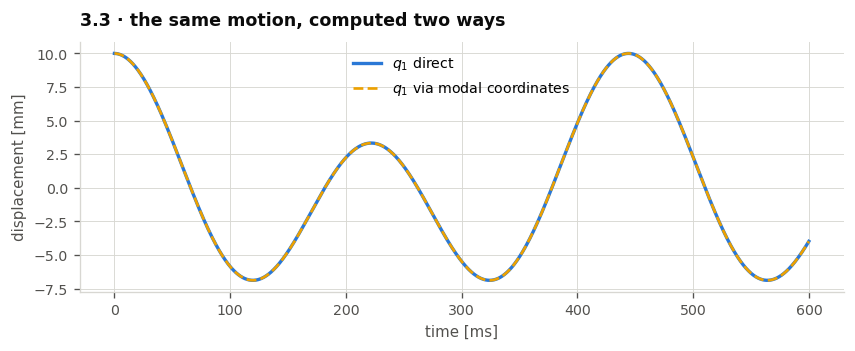

max difference: 5.377642775528102e-17


In [5]:
Phi = V
print("Phi^T M Phi =\n", Phi.T @ M @ Phi)
print("\nPhi^T K Phi =\n", Phi.T @ K @ Phi)
print("\nOff-diagonal magnitudes: "
      f"{np.max(np.abs(Phi.T @ K @ Phi - np.diag(np.diag(Phi.T @ K @ Phi)))):.2e}")

# integrate both forms and compare
def simulate(Mx, Kx, q0, T=0.6, n=3000):
    dt = T / n
    q = np.array(q0, float); v = np.zeros_like(q)
    Minv = np.linalg.inv(Mx)
    out = np.zeros((n, len(q)))
    for i in range(n):
        v += dt * (Minv @ (-Kx @ q))
        q += dt * v
        out[i] = q
    return np.linspace(0, T, n), out

q0 = np.array([0.01, 0.0])
t, q_direct = simulate(M, K, q0)
eta0 = np.linalg.solve(Phi, q0)
_, eta = simulate(Phi.T @ M @ Phi, Phi.T @ K @ Phi, eta0)
q_modal = (Phi @ eta.T).T

fig, ax = plt.subplots(figsize=(7.2, 3.0))
ax.plot(t*1000, q_direct[:, 0]*1000, color=SERIES[0], label="$q_1$ direct")
ax.plot(t*1000, q_modal[:, 0]*1000, color=SERIES[3], ls="--", lw=1.6,
        label="$q_1$ via modal coordinates")
tidy(ax, "3.3 · the same motion, computed two ways", "time [ms]", "displacement [mm]")
ax.legend()
plt.tight_layout(); plt.show()
print("max difference:", np.max(np.abs(q_direct - q_modal)))

## 3.4 · Modal mass is a bookkeeping quantity, not a physical one

Because mode shapes have arbitrary scale, so does modal mass — scale the shape by
$c$ and $m_r$ scales by $c^2$. What is *not* arbitrary is any physical answer,
because the scale cancels: in $\{u^r\}\{u^r\}^\mathsf{T}\{F\}/m_r$ the numerator
scales by $c^2$ too.

In [6]:
for c in (1.0, 5.0, 0.1):
    u = c * V[:, 0]
    mr_ = u @ M @ u
    F = np.array([1.0, 0.0])
    contribution = u * (u @ F) / mr_
    print(f"scale c = {c:4.1f}:  modal mass = {mr_:9.4f}   "
          f"contribution to response = {contribution}")
print("\nModal mass changes; the physical contribution does not.")

scale c =  1.0:  modal mass =    1.5000   contribution to response = [0.1667 0.3333]
scale c =  5.0:  modal mass =   37.5000   contribution to response = [0.1667 0.3333]
scale c =  0.1:  modal mass =    0.0150   contribution to response = [0.1667 0.3333]

Modal mass changes; the physical contribution does not.


### Repeated frequencies, again

If two frequencies coincide, `eigh` still hands you an $[M]$-orthogonal pair — it
picks one arbitrarily out of the valid subspace. Fine numerically, dangerous if
your design *means* something by "mode 2".

---

**Next:** [4 · Participation, and how to silence a mode](04_participation_and_silent_modes.ipynb)